In [1]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor


In [2]:
data = pd.read_csv("fashion-mnist_train.csv")

In [3]:
data

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
x,y = data.drop(['label'],axis = 1), data['label']

In [5]:
seed = 42

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = seed)

label
5    4262
8    4238
0    4217
9    4206
1    4205
4    4195
2    4186
3    4178
7    4159
6    4154
Name: count, dtype: int64

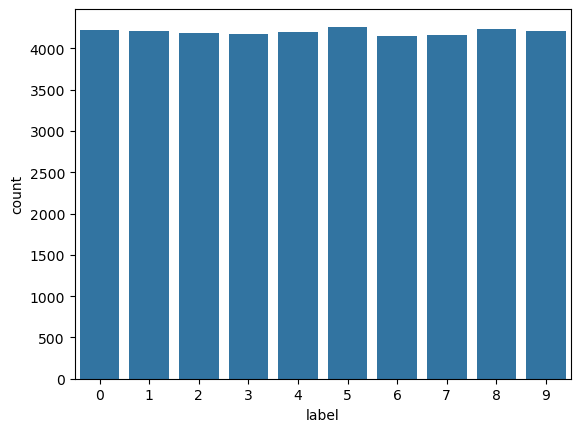

In [7]:
g = sns.countplot(x=y_train)
y_train.value_counts()

In [8]:
x_train = x_train/255.0
x_test = x_test/255.0

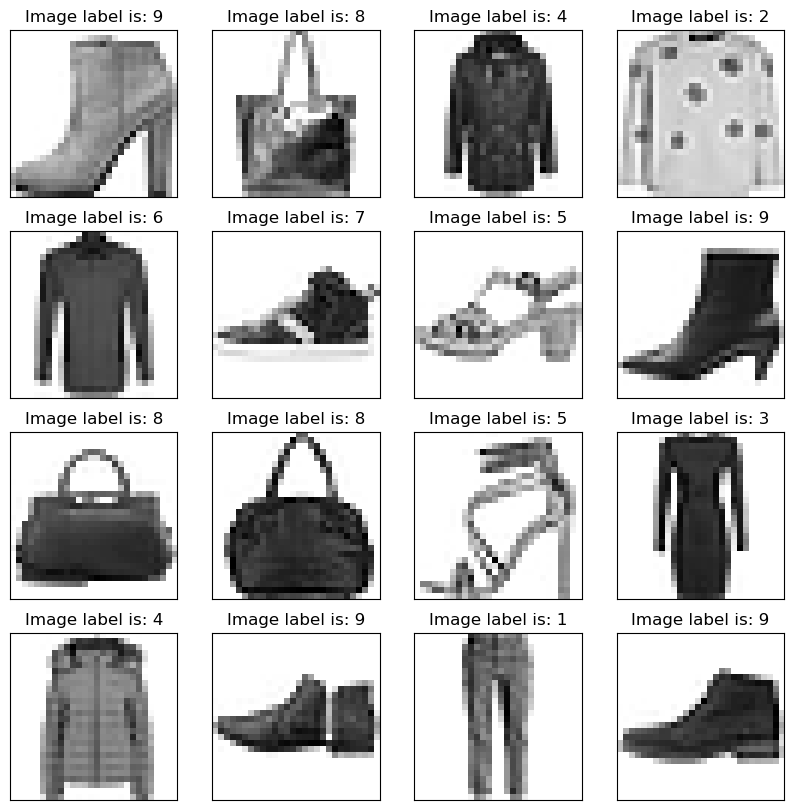

In [9]:
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = x_train.iloc[i].values.reshape(28,28)
    label = y_train.iloc[i]
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title("Image label is: {}".format(label))
plt.show()

In [17]:
x_train = x_train.astype('float').to_numpy()
x_test = x_test.astype('float').to_numpy()


In [18]:
x_train_np = x_train.reshape(-1, 1, 28, 28)
x_test_np  = x_test.reshape(-1, 1, 28, 28)

In [19]:

x_train= torch.from_numpy(x_train)
x_test= torch.from_numpy(x_test)

In [20]:

y_train= torch.from_numpy(y_train.astype('int64').to_numpy())
y_test= torch.from_numpy(y_test.astype('int64').to_numpy())

In [21]:
train_data = TensorDataset(x_train,y_train)
test_data = TensorDataset(x_test,y_test)

In [22]:
batch_size = 64
train = DataLoader(train_data,batch_size = batch_size,shuffle=True)
test = DataLoader(test_data,batch_size = batch_size)

Shape of x [N,C,H,W]: torch.Size([64, 784])
Shape of y: torch.Size([64])<built-in method type of Tensor object at 0x31c8e7830>


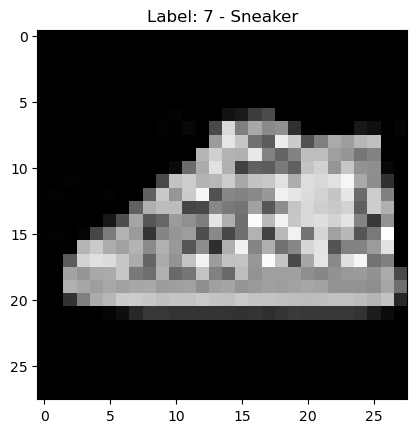

Labels vatch shape: torch.Size([64])


In [23]:
labels_map={
    0: 'T-shirt',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle Boot',
}

for x,y in train:
    train_feature,train_label = x,y
    print(f'Shape of x [N,C,H,W]: {x.shape}')
    print(f'Shape of y: {y.shape}{y.type}')
    image = train_feature[0].squeeze().reshape(28,28)
    label = train_label[0]
    sample_idx = label.item()
    plt.title(f"Label: {label} - {labels_map[sample_idx]}")
    plt.imshow(image,cmap='gray')
    plt.show()
    print(f'Labels vatch shape: {train_label.size()}')
    break

In [24]:
device = 'cuda' if torch.cuda.is_available else 'cpu'
print(f'Using {device} device for trainning')

Using cuda device for trainning


In [25]:
class network(nn.Module):
    def __init__(self):
        super(network,self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28,500),
            nn.ReLU(),
            nn.Linear(500,500),
            nn.ReLU(),
            nn.Linear(500,10)
        )
    def forward(self,x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [32]:
import torch.optim as optim
model = network().to('cpu')
learn_rate = 0.05
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr = learn_rate)

In [27]:
def trainloop(dataloader,model,loss_fn,optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch,(x,y) in enumerate(dataloader):
        x,y = x.to('cpu').float(), y.to('cpu').long()
        prediction = model(x)
        loss = loss_fn(prediction,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 ==0:
            loss,current = loss.item(),batch*len(x)
            print(f'loss is {loss:>7f} [{current:>5d}/{size:>5d}]')

In [28]:
def evaluate (dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X,Y in dataloader:
            X,Y = X.to('cpu').float(),Y.to('cpu').long()
            pred = model(X)
            test_loss += loss_fn(pred, Y).item()
            correct += (pred.argmax(1) == Y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f'Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n')

In [33]:
for i in range(epochs):
    print(f"Epoch {i+1}\n-------------------------------")
    trainloop(train, model, loss_fn, optimizer)
    evaluate(test, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss is 2.296719 [    0/42000]
loss is 1.146314 [ 6400/42000]
loss is 0.758462 [12800/42000]
loss is 0.575646 [19200/42000]
loss is 0.517294 [25600/42000]
loss is 0.594405 [32000/42000]
loss is 0.645077 [38400/42000]
Test Error: 
 Accuracy: 79.7%, Avg loss: 0.586614 

Epoch 2
-------------------------------
loss is 0.601348 [    0/42000]
loss is 0.648318 [ 6400/42000]
loss is 0.417240 [12800/42000]
loss is 0.332734 [19200/42000]
loss is 0.427426 [25600/42000]
loss is 0.391587 [32000/42000]
loss is 0.572471 [38400/42000]
Test Error: 
 Accuracy: 79.4%, Avg loss: 0.540034 

Epoch 3
-------------------------------
loss is 0.667385 [    0/42000]
loss is 0.491138 [ 6400/42000]
loss is 0.626131 [12800/42000]
loss is 0.419386 [19200/42000]
loss is 0.453747 [25600/42000]
loss is 0.365259 [32000/42000]
loss is 0.431013 [38400/42000]
Test Error: 
 Accuracy: 84.0%, Avg loss: 0.448371 

Epoch 4
-------------------------------
loss is 0.599469 [    0/42000]
lo